<a href="https://colab.research.google.com/github/projet-virage/ActiveTransportation/blob/main/EnvironmentalVariables_MediumComplexity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Latest Version of the Agent-Based Transportation Model: GitHub–Google Colab Integration and Synchronization Workflow

In [ ]:
!pip install mesa
!pip install osmnx
!pip install optuna

In [3]:
from mesa import Model, Agent
from mesa.datacollection import DataCollector
from mesa.time import Schedule
import os

import geopandas as gpd
import networkx as nx
import osmnx
import numpy as np
import random
from shapely.geometry import Point
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import differential_evolution
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import time
import optuna
import math
from scipy.stats import truncnorm

# Importing spatial data and preprocessing them

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = os.environ.get("DATA_FOLDER", "/content/drive/MyDrive/Transportation_UrbanHealth")
# Importing Census Data
df = pd.read_csv(os.path.join(data_path, "Census_data.csv")).iloc[1:,:]
gender = pd.read_csv(os.path.join(data_path, "Gender.csv")).drop(columns=['Population']).dropna().reset_index(drop=True)

# Importing Spatial Data
MTL_DA = gpd.read_file(os.path.join(data_path, "DA_MTL_MTM.shp"))[['UID_12','geometry']].rename(columns={'UID_12':'DA_name'})
residential = gpd.read_file(os.path.join(data_path, "Residential_MTM.shp"))
workplaces = gpd.read_file(os.path.join(data_path, "workplaces.shp"))
stm = gpd.read_file(os.path.join(data_path, "STM_MTM.shp"))
Bikelanes = gpd.read_file(os.path.join(data_path, "VQ_bikelanes.shp"))

# Nodes and Edges for the networks
Netnodes = gpd.read_file(os.path.join(data_path, "Nodes.shp"))
Netedges_car = gpd.read_file(os.path.join(data_path, "Edges_car.shp")).set_index(['u', 'v', 'key'])
Netedges_walk = gpd.read_file(os.path.join(data_path, "Edges_walk.shp")).set_index(['u', 'v', 'key'])
Netedges_bike = gpd.read_file(os.path.join(data_path, "Edges_bike.shp")).set_index(['u', 'v', 'key'])
Netedges_transit = gpd.read_file(os.path.join(data_path, "Edges_transit.shp")).set_index(['u', 'v', 'key'])

In [6]:
gender[['Male',	'Female']] = gender[['Male',	'Female']].apply(lambda x: x/(gender['Male'] + gender['Female']))

df_census_data = df.rename(columns={
    "COL0": "DA_name",
    "COL1": "population",
    "COL2": "age_15_64",
    "COL3": "income_no_total",
    "COL4": "income_under_10k",
    "COL5": "income_10k_20k",
    "COL6": "income_20k_30k",
    "COL7": "income_30k_40k",
    "COL8": "income_40k_50k",
    "COL9": "income_50k_60k",
    "COL10": "income_60k_70k",
    "COL11": "income_70k_80k",
    "COL12": "income_80k_90k",
    "COL13": "income_90k_100k",
    "COL15": "income_100k_150k",
    "COL16": "income_150k_plus",
    "COL17": "Car",
    "COL18": "Transit",
    "COL19": "Walk",
    "COL20": "Bike",
    "COL21": "Commute_other",
    "COL22": "commute_time_less_15",
    "COL23": "commute_time_15_30",
    "COL24": "commute_time_30_45",
    "COL25": "commute_time_45_60",
    "COL26": "commute_time_more_60"
})

df_census_data.drop(columns = "COL14", inplace = True)
df_census_data.dropna(inplace=True)

df_census_data['All_modes'] = df_census_data['Car'] + df_census_data['Transit'] + df_census_data['Walk'] + df_census_data['Bike']

df_census_data["Pop_with_income"] = df_census_data[['income_no_total', 'income_under_10k', 'income_10k_20k', "income_20k_30k", "income_30k_40k", "income_40k_50k","income_50k_60k",
                        "income_60k_70k", "income_70k_80k", "income_80k_90k", "income_90k_100k", "income_100k_150k", "income_150k_plus"]].sum(axis= 1)

# Percentage of each group
df_census_data[['income_no_total', 'income_under_10k', 'income_10k_20k', "income_20k_30k", "income_30k_40k", "income_40k_50k","income_50k_60k",
                        "income_60k_70k", "income_70k_80k", "income_80k_90k", "income_90k_100k", "income_100k_150k", "income_150k_plus"]]= df_census_data[['income_no_total', 'income_under_10k', 'income_10k_20k', "income_20k_30k", "income_30k_40k", "income_40k_50k","income_50k_60k",
                        "income_60k_70k", "income_70k_80k", "income_80k_90k", "income_90k_100k", "income_100k_150k", "income_150k_plus"]].apply(lambda x: x/df_census_data["Pop_with_income"])


df_census_data["income_no_total"] = 1 - df_census_data[['income_under_10k', 'income_10k_20k', "income_20k_30k", "income_30k_40k", "income_40k_50k","income_50k_60k",
                        "income_60k_70k", "income_70k_80k", "income_80k_90k", "income_90k_100k", "income_100k_150k", "income_150k_plus"]].sum(axis= 1)


df_census_data['commute_time_15_30'] = df_census_data['commute_time_less_15'] + df_census_data['commute_time_15_30']
df_census_data['Total_commuters'] = df_census_data['commute_time_15_30'] + df_census_data['commute_time_30_45'] + df_census_data['commute_time_45_60'] + df_census_data['commute_time_more_60']
df_census_data[['commute_time_15_30', 'commute_time_30_45', 'commute_time_45_60', 'commute_time_more_60']] = df_census_data[['commute_time_15_30', 'commute_time_30_45', 'commute_time_45_60', 'commute_time_more_60']].apply(lambda x: x/df_census_data["Total_commuters"])

df_census_data['commute_time_15_30'] = 1 - (df_census_data['commute_time_30_45'] + df_census_data['commute_time_45_60'] + df_census_data['commute_time_more_60'])
df_census_data.drop(columns=['Total_commuters','commute_time_less_15', "age_15_64","Commute_other", "Pop_with_income"], inplace=True)

Census_df = pd.merge(df_census_data, gender, how="left", on="DA_name")

# Merging the cencus data with the DA
montreal_da =pd.merge(MTL_DA, Census_df, on="DA_name", how= 'right').copy()

# Calculating the population density
montreal_da['Area'] = montreal_da.geometry.area / 1000000 # Area in Km2
montreal_da['pop_dens'] = montreal_da['population'] / montreal_da['Area']

In [7]:
montreal_da.columns

Index(['DA_name', 'geometry', 'population', 'income_no_total',
       'income_under_10k', 'income_10k_20k', 'income_20k_30k',
       'income_30k_40k', 'income_40k_50k', 'income_50k_60k', 'income_60k_70k',
       'income_70k_80k', 'income_80k_90k', 'income_90k_100k',
       'income_100k_150k', 'income_150k_plus', 'Car', 'Transit', 'Walk',
       'Bike', 'commute_time_15_30', 'commute_time_30_45',
       'commute_time_45_60', 'commute_time_more_60', 'All_modes', 'Male',
       'Female', 'Area', 'pop_dens'],
      dtype='object')

# Creating Networks

In [8]:
nodex = Netnodes.join(Netnodes.get_coordinates()).set_index('nodeid')[['x', 'y', 'geometry']]

# Load network
netx_car = osmnx.graph_from_gdfs(nodex, Netedges_car)
netx_walk = osmnx.graph_from_gdfs(nodex, Netedges_walk)
netx_bike = osmnx.graph_from_gdfs(nodex, Netedges_bike)
netx_transit = osmnx.graph_from_gdfs(nodex, Netedges_transit)

# Plotting Network

In [ ]:
# Car network
fig, ax = osmnx.plot.plot_graph(netx_car, edge_alpha=.3, node_color="r", node_size=5, node_zorder=0, node_alpha=.2)

# Walk network
fig, ax = osmnx.plot.plot_graph(netx_walk, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Bike network
fig, ax = osmnx.plot.plot_graph(netx_bike, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Transit network
fig, ax = osmnx.plot.plot_graph(netx_transit, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Model development

In [9]:
# The main function
class TransportModel(Model):

  def __init__(self, n_rep, DA_MTL, Res, Net_car, Net_walk, Net_bike, Net_transit, Wrk_N, STM_N, bikelanes):
    super().__init__()
    self.agent_list = []
    self.Each_agent_represents = n_rep
    self.montreal_da = DA_MTL
    self.residential = Res
    self.betas = None
    self.bikelanes = bikelanes

    self.Gc = Net_car
    self.Gw = Net_walk
    self.Gb = Net_bike
    self.Gstm = Net_transit

    self.workplaces = Wrk_N.copy()
    self.stms = STM_N.copy()

    self.car_cache = {}
    self.walk_cache = {}
    self.transit_cache = {}
    self.bike_cache = {}

    # Add network nodes
    self.stms['network_node'] = osmnx.distance.nearest_nodes(self.Gw, self.stms.geometry.x, self.stms.geometry.y)
    self.stm_tree = cKDTree(np.column_stack([self.stms.geometry.x, self.stms.geometry.y]))
    #----------------------------------------------------------------------
    # Residential
    self.residential["res_id"] = np.arange(len(self.residential))

    x = self.residential.centroid.x.values
    y = self.residential.centroid.y.values

    self.residential["network_node"] = osmnx.distance.nearest_nodes(self.Gw, x, y)
    self.res_lookup = (self.residential.set_index("res_id")[["network_node"]].to_dict("index"))
    #----------------------------------------------------------------------
    # Workplaces
    self.workplaces["wrk_id"] = np.arange(len(self.workplaces))

    xw = self.workplaces.geometry.x.values
    yw = self.workplaces.geometry.y.values

    self.workplaces["network_node"] = osmnx.distance.nearest_nodes(self.Gw, xw, yw)
    self.wrk_lookup = (self.workplaces.set_index("wrk_id")[["network_node"]].to_dict("index"))

    # Workplace KDTree
    self.workplace_tree = cKDTree(np.column_stack([self.workplaces.geometry.x, self.workplaces.geometry.y]))
    #-----------------------------------------------------------------------------------------
    # Create agents
    self.create_agents()

    # Data collection
    self.datacollector = DataCollector(
        agent_reporters={
            "DA_ID": "DA_ID",
            "age": "age",
            "gender": "gender", # 0 represents female/woman and 1 represents male/man
            "income": "income",
            # Car time
            "time_car": "time_car",
            # STM times encompasses three components
            "time_home_stm": "time_home_stm",
            "time_stm_stm": "time_stm_stm",
            "time_stm_work": "time_stm_work",
            # Bike time
            "time_bike": "time_bike",
            # Walk time
            "time_walk": "time_walk",
            "pop_dens": "pop_dens",
            "proximity_to_bikelane": "proximity_to_bikelane",
            "mode_choice": "mode_choice"
        }
    )

    # Activate agents in random order
    for agentt in tqdm(random.sample(self.agent_list, len(self.agent_list)), desc= "Agents activation"):
      agentt.step()

    self.compute_all_travel_times(self.agent_list)
    self.datacollector.collect(self)

  # --------------------------------------------------------
  def closest_candidate_node(self, G, source_node, candidate_gdf, tree):

    source_xy = (G.nodes[source_node]['x'],G.nodes[source_node]['y'])

    distance, idx = tree.query(source_xy)
    return candidate_gdf.iloc[idx]['network_node']
  # --------------------------------------------------------
  def create_agents(self):

    pbar = tqdm(self.montreal_da.iterrows(), total=len(self.montreal_da))
    for _, da in pbar:
      pbar.set_description(f"Creating agents for DA: {da['DA_name']}")

      if da['Car'] == 0 and da['Transit'] == 0 and da['Bike'] == 0 and da['Walk'] == 0:
        continue

      else:
        # Residential polygons inside this DA
        res = self.residential[self.residential.intersects(da.geometry)]
        if res.empty:
          continue

        # Initializing Agents (age_15–64)

        num_adults = round((da['Car'] / self.Each_agent_represents)) + round((da['Transit'] / self.Each_agent_represents))+ round((da['Bike'] / self.Each_agent_represents)) + round((da['Walk'] / self.Each_agent_represents))

        male_num = round(da['Male'] * num_adults)
        female_num = num_adults - male_num

        # Male initialization
        for _ in range(male_num):

          poly = res.iloc[[np.random.randint(len(res))]]

          agent = PersonAgent(self, {
              'age': random.randint(15, 64),
              'gender': 1,
              'age_group': 'adult',
              'DA_ID': da['DA_name'],
              'income': 0,
              'res_id': poly['res_id'].values[0],
              'x': poly.geometry.centroid.x.values[0],
              'y': poly.geometry.centroid.y.values[0],
              'proximity_to_bikelane': None,
              'commute_distance': None,
              'pop_dens': da['pop_dens'] # Agent is initialized in a DA with a population density of  pop_dens
              })

          self.agent_list.append(agent)

        # Female initialization
        for _ in range(female_num):
          poly = res.iloc[[np.random.randint(len(res))]]

          agent = PersonAgent(self, {
              'age': random.randint(15, 64),
              'gender': 0,
              'age_group': 'adult',
              'DA_ID': da['DA_name'],
              'income': 0,
              'res_id': poly['res_id'].values[0],
              'x': poly.geometry.centroid.x.values[0],
              'y': poly.geometry.centroid.y.values[0],
              'proximity_to_bikelane': None,
              'commute_distance': None,
              'pop_dens': da['pop_dens']
          })

          self.agent_list.append(agent)

        # Calculating the number of the agents in each coomute group

        num_agents_wit_commute_time_30_45 = math.floor(da['commute_time_30_45'] * num_adults)
        num_agents_wit_commute_time_45_60 = math.floor(da['commute_time_45_60'] * num_adults)
        num_agents_wit_commute_time_more_60 = math.floor(da['commute_time_more_60'] * num_adults)
        num_agents_wit_commute_time_15_30 = num_adults - (num_agents_wit_commute_time_30_45 + num_agents_wit_commute_time_45_60 + num_agents_wit_commute_time_more_60)

        commute_categories = (
            [4000] * num_agents_wit_commute_time_15_30 +
            [8000] * num_agents_wit_commute_time_30_45 +
            [13000] * num_agents_wit_commute_time_45_60 +
            [18000] * num_agents_wit_commute_time_more_60
        )

        # Randomize which agent receives which category
        random.shuffle(commute_categories)

        agents_with_DAs = [a for a in self.agent_list if a.DA_ID == da['DA_name']]
        for agent, category in zip(agents_with_DAs, commute_categories):
          agent.commute_distance = category


        # Calculating the number of the agents in each income group and randomly setting values to income attribute of corresponding agent

        num_income_under_10k = math.floor(da['income_under_10k'] * num_adults)
        num_income_10k_20k = math.floor(da['income_10k_20k'] * num_adults)
        num_income_20k_30k = math.floor(da['income_20k_30k'] * num_adults)
        num_income_30k_40k = math.floor(da['income_30k_40k'] * num_adults)
        num_income_40k_50k = math.floor(da['income_40k_50k'] * num_adults)
        num_income_50k_60k = math.floor(da['income_50k_60k'] * num_adults)
        num_income_60k_70k = math.floor(da['income_60k_70k'] * num_adults)
        num_income_70k_80k = math.floor(da['income_70k_80k'] * num_adults)
        num_income_80k_90k = math.floor(da['income_80k_90k'] * num_adults)
        num_income_90k_100k = math.floor(da['income_90k_100k'] * num_adults)
        num_income_100k_150k = math.floor(da['income_100k_150k'] * num_adults)
        num_income_150k_plus = math.floor(da['income_150k_plus'] * num_adults)

        num_without_income = num_adults - (num_income_under_10k + num_income_10k_20k + num_income_20k_30k + num_income_30k_40k +
                                           num_income_40k_50k + num_income_50k_60k + num_income_60k_70k + num_income_70k_80k + num_income_80k_90k +
                                           num_income_90k_100k + num_income_100k_150k + num_income_150k_plus)

        income_categories = (
            ["without_income"] * num_without_income +
            ["under_10k"] * num_income_under_10k +
            ["10k_20k"] * num_income_10k_20k +
            ["20k_30k"] * num_income_20k_30k +
            ["30k_40k"] * num_income_30k_40k +
            ["40k_50k"] * num_income_40k_50k +
            ["50k_60k"] * num_income_50k_60k +
            ["60k_70k"] * num_income_60k_70k +
            ["70k_80k"] * num_income_70k_80k +
            ["80k_90k"] * num_income_80k_90k +
            ["90k_100k"] * num_income_90k_100k +
            ["100k_150k"] * num_income_100k_150k +
            ["150k_plus"] * num_income_150k_plus
        )

        # Randomize which agent receives which category
        random.shuffle(income_categories)


        # ---------------------------------------------------------
        # Defining the normal distribution for each category

        income_distributions = {
            "without_income": (0,      0,      0,      0),
            "under_10k":  (0,      9999,   5000,   2500),
            "10k_20k":    (10000,  19999,  15000,  2500),
            "20k_30k":    (20000,  29999,  25000, 2500),
            "30k_40k":    (30000,  39999,  35000, 2500),
            "40k_50k":    (40000,  49999,  45000, 2500),
            "50k_60k":    (50000,  59999,  55000, 2500),
            "60k_70k":    (60000,  69999,  65000, 2500),
            "70k_80k":    (70000,  79999,  75000, 2500),
            "80k_90k":    (80000,  89999,  85000, 2500),
            "90k_100k":   (90000,  99999,  95000, 2500),
            "100k_150k":  (100000, 149999, 125000, 12500),
            "150k_plus":  (150000, 250000, 175000, 25000)
        }


        # ---------------------------------------------------------

        for agent, category in zip(agents_with_DAs, income_categories):
          if category == "without_income":
            agent.income = 0
          else:
            low, high, mean, std = income_distributions[category]

            # Truncated normal: guarantees income stays within category
            a = (low - mean) / std
            b = (high - mean) / std

            agent.income = round(truncnorm.rvs(a, b,loc=mean,scale=std))

  def compute_mode_shares(self): # This function is defined to be used only in model calibration

    results = {}

    for _, row in self.montreal_da.iterrows():

      if row['Car'] == 0 and row['Transit'] == 0 and row['Bike'] == 0 and row['Walk'] == 0: # Opting out the DA with no people using any four transportation modes (i.e., outliers)
        continue

      res = self.residential[self.residential.intersects(row.geometry)]
      if res.empty:
        continue

      da_id = row['DA_name']

      agentss = [a for a in self.agent_list if a.age_group == "adult" and a.DA_ID == da_id]

      counts = {'auto':0, 'transit':0, 'bike':0, 'walk':0}

      for a in agentss:
        if a.mode_choice == "auto": counts['auto'] += 1
        elif a.mode_choice == "transit": counts['transit'] += 1
        elif a.mode_choice == "bike": counts['bike'] += 1
        else: counts['walk'] += 1

        results[da_id] = counts.copy()

    return results


  # ==============================================================
  def _batch_shortest(self, G, origins, destinations, weight, cache):

    results = np.empty(len(origins), dtype=float)

    missing = {}

    for i, (o, d) in enumerate(zip(origins, destinations)):

        key = (o, d)

        if key in cache:
            results[i] = cache[key]

        else:
            missing.setdefault(key, []).append(i)


    if len(missing) == 0:
        return results

    unique_origins = [k[0] for k in missing]
    unique_destinations = [k[1] for k in missing]

    # Single CPU environment
    paths = osmnx.routing.shortest_path(G,unique_origins,unique_destinations,weight=weight,cpus=1)

    for path, key in zip(paths, missing.keys()):

        if path is None:
            dist = np.nan
        else:
            dist = nx.path_weight(
                G,
                path,
                weight=weight
            )

        cache[key] = dist

        for idx in missing[key]:
            results[idx] = dist


    return results

  # ==============================================================
  def compute_all_travel_times(self, agents):
    # CAR: home -----> work

    t0 = time.perf_counter()
    total_steps = 4
    stp = 1
    print(f"[{stp}/{total_steps}] Computing car travel times...")

    car_times = self._batch_shortest(self.Gc, [a.home_node_network for a in agents], [a.workplace_node_network for a in agents],"trv_time", self.car_cache)

    for a, t in zip(agents, car_times):
        a.time_car = t
        a.auto_available = np.isfinite(t)

    print(f"Done ({time.perf_counter() - t0:.1f} s)")
    #--------------------------------------------------------------------------------------------------------------------

    t1 = time.perf_counter()
    stp += 1
    print(f"[{stp}/{total_steps}] Computing walking travel times...")
    # ---------- WALK: home -> work ----------
    walk_times = self._batch_shortest(self.Gw,[a.home_node_network for a in agents],[a.workplace_node_network for a in agents],"trv_time", self.walk_cache)

    for a, t in zip(agents, walk_times):
      a.time_walk = t
      a.walk_available = np.isfinite(t)

    print(f"Done ({time.perf_counter() - t1:.1f} s)")


    #-----------------------------------------------------------------------------------------------------------------
    t2 = time.perf_counter()
    stp += 1
    print(f"[{stp}/{total_steps}] Computing STM travel times...")
    # ---------- STM: home -> home_stm_node ----------
    home_stm_times = self._batch_shortest(self.Gw,[a.home_node_network for a in agents],[a.home_stm_node_network for a in agents],"trv_time", self.walk_cache)

    # Keep only agents with reachable home -> STM
    valid_agents = []

    for a, t in zip(agents, home_stm_times):
      a.time_home_stm = t
      a.transit_available = False   # default

      if np.isfinite(t):
        valid_agents.append(a)

    # ==============================================================
    #---------- STM: home_stm_node -> work_stm_node ----------
    if len(valid_agents) > 0:
      stm_stm_times = self._batch_shortest(self.Gstm,[a.home_stm_node_network for a in valid_agents],[a.work_stm_node_network for a in valid_agents],"trv_time", self.transit_cache)

      valid_agents_2 = []

      for a, t in zip(valid_agents, stm_stm_times):
        a.time_stm_stm = t

        if np.isfinite(t):
          valid_agents_2.append(a)

    # ---------- STM: work_stm_node -> workplace ----------
    if len(valid_agents_2) > 0:

      stm_work_times = self._batch_shortest(self.Gw,[a.work_stm_node_network for a in valid_agents_2],[a.workplace_node_network for a in valid_agents_2],"trv_time", self.walk_cache)

      for a, t in zip(valid_agents_2, stm_work_times):
        a.time_stm_work = t

        if np.isfinite(t):
          a.transit_available = True

    print(f"Done ({time.perf_counter() - t2:.1f} s)")

    #-----------------------------------------------------------------------------------------------------------------


    t3 = time.perf_counter()
    stp += 1
    print(f"[{stp}/{total_steps}] Computing BIKE travel times...")
    # ---------- BIKE: home -> home ----------
    bike_times = self._batch_shortest(self.Gb,[a.home_node_network for a in agents],[a.workplace_node_network for a in agents],"trv_time", self.bike_cache)

    for a, t in zip(agents, bike_times):
      a.time_bike = t
      a.bike_available = np.isfinite(t)
    print(f"Done ({time.perf_counter() - t3:.1f} s)")


  def step(self):
    agent_df = self.datacollector.get_agent_vars_dataframe()

    agent_df["time_transit"] = agent_df["time_home_stm"] + agent_df["time_stm_stm"] + agent_df["time_stm_work"]

    for agent in self.agent_list:
      agent.compute_mode_choice(self.betas, agent_df)

In [10]:
class PersonAgent(Agent):

  def __init__(self, model, attrs):
    super().__init__(model)
    # Demographic
    self.age = attrs['age']
    self.age_group = attrs['age_group']
    self.gender = attrs['gender']
    self.DA_ID = attrs['DA_ID']
    self.income = attrs.get('income', None)
    self.x = attrs['x']
    self.y = attrs['y']
    self.commute_distance = attrs['commute_distance']
    self.pop_dens = attrs['pop_dens']
    self.proximity_to_bikelane = attrs['proximity_to_bikelane']
    self.res_id = attrs['res_id']
    self.work_id = None

    # Network home and workplace nodes
    self.home_node_network = None
    self.workplace_node_network = None

    # Closest stm node to home and workplace
    self.home_stm_node_network = None
    self.work_stm_node_network = None


    # Travel times under different transportation modes
    self.time_car = np.nan

    self.time_home_stm = np.nan
    self.time_stm_stm = np.nan
    self.time_stm_work = np.nan

    self.time_bike = np.nan

    self.time_walk = np.nan

    # Policy related characteristics


    # Availability of the transportation mode
    self.auto_available = False
    self.walk_available = False
    self.transit_available = False
    self.bike_available = False


    # Mode
    self.mode_choice = None
  # --------------------------------------------------------
  def step(self):
    self.assign_nodes()

  # --------------------------------------------------------
  def workplaces_within_radius(self, x,y, radius):
    nearby_indices = self.model.workplace_tree.query_ball_point([x, y],r=radius)

    if not nearby_indices:
        return None

    idx = random.choice(nearby_indices)

    return self.model.workplaces.iloc[idx]["wrk_id"]
  # --------------------------------------------------------
  def assign_nodes(self):

    home = self.model.res_lookup[self.res_id]
    self.home_node_network = home["network_node"]
    # update x and y coordinate of the agent based on the home coordinate
    res = self.model.residential[self.model.residential["res_id"] == self.res_id]
    self.x = res.iloc[0].geometry.centroid.x
    self.y = res.iloc[0].geometry.centroid.y

    self.proximity_to_bikelane = self.model.bikelanes.geometry.distance(Point(self.x, self.y)).min()

    # WORKPLACE (adults)
    if self.age_group == "adult":
      self.work_id = self.workplaces_within_radius(self.x, self.y, self.commute_distance)
      wrk = self.model.wrk_lookup[self.work_id]

    self.workplace_node_network = wrk["network_node"]

    # STM candidate nodes (nearest-neighbor lookups)
    self.home_stm_node_network = self.model.closest_candidate_node(self.model.Gw, self.home_node_network, self.model.stms, self.model.stm_tree)
    self.work_stm_node_network = self.model.closest_candidate_node(self.model.Gw, self.workplace_node_network, self.model.stms, self.model.stm_tree)

  # --------------------------------------------------------
  def compute_mode_choice(self, betas, df):
    (
    β1,   # time_auto
    β2,   # age_auto
    β3,   # gender
    β4,   # income_auto
    β5,   # population_density
    β6,   # age × time_auto
    β7,   # income × time_auto

    β8,   # time_transit
    β9,   # age_transit
    β10,   # gender
    β11,   # income_transit
    β12,   # population_density
    β13,   # age × time_transit
    β14,  # income × time_transit

    β15,  # time_bike
    β16,  # age_bike
    β17,   # gender
    β18,  # income_bike
    β19,   # population_density
    β20,  # proximity_to_bikelane
    β21,  # age × time_bike
    β22,  # income × time_bike

    β23,  # time_walk
    β24,  # age_walk
    β25,   # gender
    β26,  # income_walk
    β27,   # population_density
    β28,  # age × time_walk
    β29,  # income × time_walk

    ASC_auto,
    ASC_transit,
    ASC_bike) = betas

    # Z-score standardization
    ###########################################################

    def safe_standardize(value, series):

        series = np.asarray(series, dtype=float)
        series = series[np.isfinite(series)]

        if len(series) == 0:
            return 0.0

        mean = np.mean(series)
        std = np.std(series)

        if std == 0:
            return 0.0

        if pd.isna(value):
            return np.nan

        return (value - mean) / std

    # Standardization of the variables
    time_auto_st = safe_standardize(self.time_car, df["time_car"])

    time_transit_st = safe_standardize(self.time_home_stm + self.time_stm_stm + self.time_stm_work,df["time_home_stm"] +df["time_stm_stm"] +df["time_stm_work"])

    time_bike_st = safe_standardize(self.time_bike,df["time_bike"])

    time_walk_st = safe_standardize(self.time_walk,df["time_walk"])

    income_st = safe_standardize(self.income, df["income"])
    age_st = safe_standardize(self.age, df["age"])
    population_density_st = safe_standardize(self.pop_dens, df["pop_dens"])
    prx_bikelanes = safe_standardize(self.proximity_to_bikelane, df["proximity_to_bikelane"])

    # Verifying if there is any Nan in the values
    if np.isnan(time_auto_st):
      self.auto_available = False
      U_auto = -np.inf

    if np.isnan(time_transit_st):
      self.transit_available = False
      U_transit = -np.inf

    if np.isnan(time_bike_st):
      self.bike_available = False
      U_bike = -np.inf

    if np.isnan(time_walk_st):
      self.walk_available = False
      U_walk = -np.inf

    # Utilities
    if self.auto_available == True:
      U_auto = (ASC_auto
                + β1 * time_auto_st
                + β2 * age_st
                + β3 * self.gender
                + β4 * income_st
                + β5 * population_density_st
                + β6 * age_st * time_auto_st
                + β7 * income_st * time_auto_st
                )
    else:
      U_auto = -np.inf

    if self.transit_available == True:
      U_transit = (
          ASC_transit
          + β8 * time_transit_st
          + β9 * age_st
          + β10 * self.gender
          + β11 * income_st
          + β12 * population_density_st
          + β13 * age_st * time_transit_st
          + β14 * income_st * time_transit_st)
    else:
      U_transit = -np.inf

    if self.bike_available == True:
      U_bike = (
          ASC_bike
        + β15 * time_bike_st
        + β16 * age_st
        + β17 * self.gender
        + β18 * income_st
        + β19 * population_density_st
        + β20 * prx_bikelanes
        + β21 * age_st * time_bike_st
        + β22 * income_st * time_bike_st)
    else:
      U_bike = -np.inf

    if self.walk_available == True:
      U_walk = (
          β23 * time_walk_st
        + β24 * age_st
        + β25 * self.gender
        + β26 * income_st
        + β27 * population_density_st
        + β28 * age_st * time_walk_st
        + β29 * income_st * time_walk_st)
    else:
      U_walk = -np.inf

    # Calculation of probabilities
    utilities = np.array([U_auto, U_transit, U_bike, U_walk])

    exp_u = np.exp(utilities)
    sum_exp = np.sum(exp_u)

    modes = ["auto", "transit", "bike", "walk"]

    if sum_exp == 0 or np.isnan(sum_exp) or np.isinf(sum_exp):
      self.mode_choice = random.choice(["auto", "transit", "bike", "walk"])
    else:
      probs = exp_u / sum_exp
      self.mode_choice = modes[np.argmax(probs)]

#Considering each agent as the represener of 50 people

In [11]:
# Initialize the transport model
Transport_model = TransportModel(n_rep = 50, DA_MTL = montreal_da, Res = residential, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, STM_N = stm, bikelanes=Bikelanes)


Agents activation: 100%|██████████| 12340/12340 [04:44<00:00, 43.36it/s]


[1/4] Computing car travel times...
Done (99.6 s)
[2/4] Computing walking travel times...
Done (135.6 s)
[3/4] Computing STM travel times...
Done (86.5 s)
[4/4] Computing BIKE travel times...
Done (141.1 s)


# Calibration

In [14]:
def calibration_error(betas, model, n_steps=1, save_results=False):

  # ============================================================
  # Run the model for n_steps
  # ============================================================
  # Give the model the current Optuna parameters
  model.betas = betas

  for step in range(n_steps):
    model.step()

  sim = model.compute_mode_shares()

  total_error = 0.0
  total_weight = 0.0

  calibration_records = []

  observed_global = np.zeros(4)
  simulated_global = np.zeros(4)

  pbar = tqdm(model.montreal_da.iterrows(), total=len(model.montreal_da))

  for _, da in pbar:

      pbar.set_description(f"Calibrating DA: {da['DA_name']}")

      if (da["Car"] == 0 and da["Transit"] == 0 and da["Bike"] == 0 and da["Walk"] == 0):
          continue

      res = model.residential[model.residential.intersects(da.geometry)]

      if res.empty:
          continue

      da_id = da["DA_name"]

      if da_id not in sim:
          continue

      observed_counts = np.array([
          round(da["Car"] / model.Each_agent_represents),
          round(da["Transit"] / model.Each_agent_represents),
          round(da["Bike"] / model.Each_agent_represents),
          round(da["Walk"] / model.Each_agent_represents)
      ], dtype=float)

      simulated_counts = np.array([
          sim[da_id]["auto"],
          sim[da_id]["transit"],
          sim[da_id]["bike"],
          sim[da_id]["walk"]
      ], dtype=float)

      observed_global += observed_counts
      simulated_global += simulated_counts

      obs_total = observed_counts.sum()
      sim_total = simulated_counts.sum()

      if obs_total == 0 or sim_total == 0:
          continue


      observed_share = observed_counts / obs_total
      simulated_share = simulated_counts / sim_total

      share_error = np.mean((observed_share-simulated_share)**2)

      total_error += obs_total * share_error
      total_weight += obs_total

      calibration_records.append({

          "DA_name": da_id,

          "Obs_Auto": observed_counts[0],
          "Obs_Transit": observed_counts[1],
          "Obs_Bike": observed_counts[2],
          "Obs_Walk": observed_counts[3],

          "Sim_Auto": simulated_counts[0],
          "Sim_Transit": simulated_counts[1],
          "Sim_Bike": simulated_counts[2],
          "Sim_Walk": simulated_counts[3],

          "Error": share_error,

      })

  # ============================================================
  # Global penalties
  # ============================================================

  if total_weight == 0:
      return np.inf

  local_error = total_error / total_weight

  obs_share_global = observed_global / observed_global.sum()
  sim_share_global = simulated_global / simulated_global.sum()

  global_share_error = np.mean((obs_share_global - sim_share_global)**2)

  final_error = (0.2 * local_error + 0.8 * global_share_error)

  # ============================================================
  # Save results
  # ============================================================

  if save_results:

    calibration_df = pd.DataFrame(calibration_records)

    calibration_df.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/DA_calibration_results.csv",index=False)

    df_updated = model.datacollector.get_agent_vars_dataframe()

    df_updated.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Data_collecter_results.csv",index=False)

    print("\nObserved totals:")
    print(observed_global.astype(int))

    print("\nSimulated totals:")
    print(simulated_global.astype(int))

    print('Observed global: ', observed_global.sum())
    print('Simulated global: ', simulated_global.sum())

    print("\nObserved modal shares:")
    print(np.round(obs_share_global,3))

    print("\nSimulated modal shares:")
    print(np.round(sim_share_global,3))

    print("\nLocal error:", local_error)
    print("Global share error:", global_share_error)
    print("Final objective:", final_error)

    modes = ["Auto","Transit","Bike","Walk"]

    x = np.arange(len(modes))
    width = 0.35

    plt.figure(figsize=(8,6))

    plt.bar(x-width/2,observed_global,width,label="Observed")

    plt.bar(x+width/2,simulated_global,width,label="Simulated")

    plt.xticks(x,modes)

    plt.ylabel("Number of people")

    plt.title("Observed vs Simulated Transportation Modes")

    plt.grid(axis="y",alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

  return final_error

[I 2026-09-29 17:52:51,703] A new study created in memory with name: no-name-d8317f28-d46c-4aa7-9e67-2cdd09475d85
Calibrating DA: 24663497: 100%|██████████| 3182/3182 [00:54<00:00, 58.07it/s]
[I 2026-09-29 17:55:21,879] Trial 0 finished with value: 0.15804847786967718 and parameters: {'β1': -1.269646768247643, 'β2': -0.07392854038512575, 'β3': 0.6959818254342154, 'β4': 0.8979877262955549, 'β5': -1.2659720393363452, 'β6': -0.8440054796637974, 'β7': -0.9419163878318005, 'β8': -0.3109565157388765, 'β9': 0.9016725176148133, 'β10': 0.6242177333881367, 'β11': -1.4691232585562963, 'β12': 1.4548647782429915, 'β13': -0.16755735919957826, 'β14': -0.7876608893217238, 'β15': -1.645441313946154, 'β16': -1.2248932352198492, 'β17': -0.5872732711213868, 'β18': -0.7128653525516433, 'β19': 0.6479175279631737, 'β20': -1.0660685811049175, 'β21': -0.38814710527762053, 'β22': -0.8605061393479582, 'β23': -1.4303179353563245, 'β24': -0.9504572350594624, 'β25': -0.13179004734889221, 'β26': -0.3222360579104797,


-----------------------------
Trial: 0
MSE: 0.158048
Betas:
[-1.26964677 -0.07392854  0.69598183  0.89798773 -1.26597204 -0.84400548
 -0.94191639 -0.31095652  0.90167252  0.62421773 -1.46912326  1.45486478
 -0.16755736 -0.78766089 -1.64544131 -1.22489324 -0.58727327 -0.71286535
  0.64791753 -1.06606858 -0.38814711 -0.86050614 -1.43031794 -0.95045724
 -0.13179005 -0.32223606  0.29951067 -0.48576556 -0.40758543 -2.72129752
  1.86035882 -3.63580701]


Calibrating DA: 24663497: 100%|██████████| 3182/3182 [00:52<00:00, 60.50it/s]
[I 2026-09-29 17:57:43,617] Trial 1 finished with value: 0.18110091733298408 and parameters: {'β1': -1.873149393678705, 'β2': -0.07667169412000008, 'β3': 1.396896099223678, 'β4': 1.2125960221746916, 'β5': -1.043079346239944, 'β6': -0.9023278859936161, 'β7': -0.3157669734878431, 'β8': -1.1417026372077774, 'β9': 0.18305735226716824, 'β10': -0.014469269666189444, 'β11': -1.4484172183271724, 'β12': 1.3639806031181732, 'β13': -0.7412200183999831, 'β14': -0.33747771564601803, 'β15': -1.3921634016256488, 'β16': -0.7198979682332838, 'β17': 0.14013083802983894, 'β18': -1.2227183167117095, 'β19': 1.4543769416468377, 'β20': -0.3450520931919394, 'β21': -0.060501058435810884, 'β22': -0.10517264957235117, 'β23': -0.8340950413183841, 'β24': -0.11718864746532476, 'β25': -1.2345224938442416, 'β26': -1.2060257063712823, 'β27': 0.0678409333658071, 'β28': -0.6746696692367357, 'β29': -0.611322710310518, 'ASC_auto': -1.37190580935


-----------------------------
Trial: 1
MSE: 0.181101
Betas:
[-1.87314939 -0.07667169  1.3968961   1.21259602 -1.04307935 -0.90232789
 -0.31576697 -1.14170264  0.18305735 -0.01446927 -1.44841722  1.3639806
 -0.74122002 -0.33747772 -1.3921634  -0.71989797  0.14013084 -1.22271832
  1.45437694 -0.34505209 -0.06050106 -0.10517265 -0.83409504 -0.11718865
 -1.23452249 -1.20602571  0.06784093 -0.67466967 -0.61132271 -1.37190581
  3.62990007 -2.14597339]


Calibrating DA: 24663497: 100%|██████████| 3182/3182 [00:58<00:00, 54.44it/s]
[I 2026-09-29 18:00:11,083] Trial 2 finished with value: 0.17277657818973688 and parameters: {'β1': -1.4521777061096075, 'β2': -0.6859558752626274, 'β3': -1.077227325075712, 'β4': 1.2032954711310595, 'β5': -1.3881740344803437, 'β6': -0.013113063399482705, 'β7': -0.22775523070334258, 'β8': -1.6125044210083639, 'β9': 0.008283175685403599, 'β10': 0.9463842853645024, 'β11': -0.43971398422857444, 'β12': 1.0935107520614809, 'β13': -0.22872965331405426, 'β14': -0.9259553482659096, 'β15': -1.3009918293386684, 'β16': -1.3261964107123054, 'β17': 1.0893102776267805, 'β18': -0.5650528097586631, 'β19': 0.4963470372789738, 'β20': -1.4052980580738248, 'β21': -0.6890176782843378, 'β22': -0.674816677973253, 'β23': -0.5772679522407751, 'β24': -0.5436637929671804, 'β25': 1.1616382277289796, 'β26': -0.7916776122570761, 'β27': 0.17939136890745255, 'β28': -0.286755212777005, 'β29': -0.23921495138310256, 'ASC_auto': 0.3676631854169

...


-----------------------------
Trial: 28
MSE: 0.030573
Betas:
[-1.70154333 -0.66373762 -0.02953498  0.35881659 -1.42190256 -0.42674863
 -0.11787472 -0.78169629  0.85292676 -0.18595942 -1.33650227  1.37223579
 -0.03242546 -0.88737841 -1.80747008 -0.8163029  -0.70941429 -1.25622337
  1.14903902 -0.74796909 -0.8263761  -0.53985533 -0.36172041 -0.29290454
 -1.48107521 -0.42212593  0.92704157 -0.45157648 -0.40275919  2.44568564
 -1.35549761 -1.26442543]


Calibrating DA: 24663497: 100%|██████████| 3182/3182 [00:58<00:00, 54.29it/s]
[I 2026-09-29 19:06:29,526] Trial 29 finished with value: 0.012954563495813625 and parameters: {'β1': -0.7199187802339708, 'β2': -1.1349119510382941, 'β3': -0.25896381829411175, 'β4': 1.0531836885718162, 'β5': -1.2508896000034313, 'β6': -0.4826488005992446, 'β7': -0.3006138970700832, 'β8': -0.8196522614539897, 'β9': 1.1405430199657476, 'β10': -0.16032355378252863, 'β11': -1.1304097265070017, 'β12': 1.3538339200056217, 'β13': -0.014212960520113893, 'β14': -0.7505714740648539, 'β15': -1.4315397186950363, 'β16': -1.367501954994138, 'β17': -1.4506744803944986, 'β18': -0.4505190349950302, 'β19': 1.354839633248479, 'β20': -1.1080784514772548, 'β21': -0.49681888779106465, 'β22': -0.7894862972671216, 'β23': -0.40337545759602683, 'β24': -0.5315832989306584, 'β25': -1.3636120207568165, 'β26': -1.0458134280713578, 'β27': 1.0715160930759715, 'β28': -0.404188056272751, 'β29': -0.5680587932646657, 'ASC_auto': 1.34873408913


-----------------------------
Trial: 29
MSE: 0.012955
Betas:
[-0.71991878 -1.13491195 -0.25896382  1.05318369 -1.2508896  -0.4826488
 -0.3006139  -0.81965226  1.14054302 -0.16032355 -1.13040973  1.35383392
 -0.01421296 -0.75057147 -1.43153972 -1.36750195 -1.45067448 -0.45051903
  1.35483963 -1.10807845 -0.49681889 -0.7894863  -0.40337546 -0.5315833
 -1.36361202 -1.04581343  1.07151609 -0.40418806 -0.56805879  1.34873409
  0.38145503 -1.4955386 ]


Calibrating DA: 24663497: 100%|██████████| 3182/3182 [01:01<00:00, 51.81it/s]



Observed totals:
[7888 3477  161  814]

Simulated totals:
[7296 4349  429  266]
Observed global:  12340.0
Simulated global:  12340.0

Observed modal shares:
[0.639 0.282 0.013 0.066]

Simulated modal shares:
[0.591 0.352 0.035 0.022]

Local error: 0.055172364040090974
Global share error: 0.0024346907843410255
Final objective: 0.012982225435491017


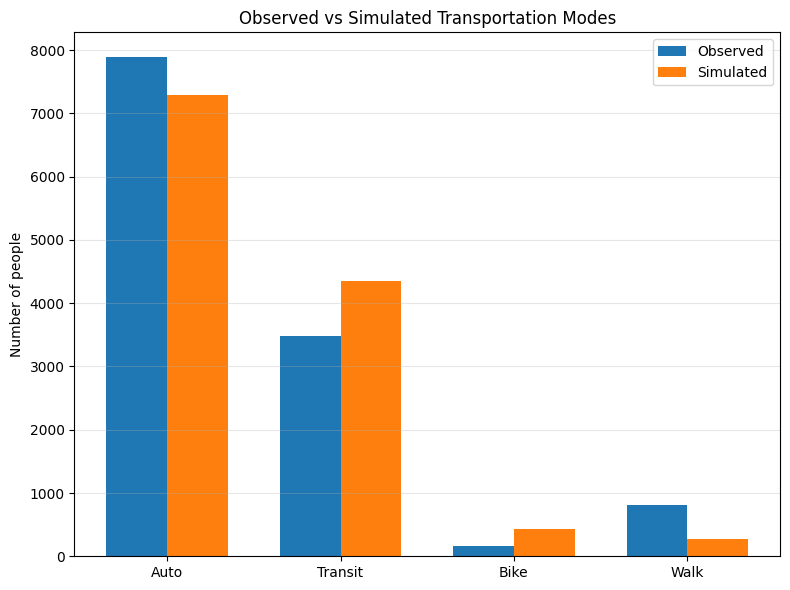


Optimization finished

Best MSE:
0.012954563495813625

Optimized coefficients:
[-0.71991878 -1.13491195 -0.25896382  1.05318369 -1.2508896  -0.4826488
 -0.3006139  -0.81965226  1.14054302 -0.16032355 -1.13040973  1.35383392
 -0.01421296 -0.75057147 -1.43153972 -1.36750195 -1.45067448 -0.45051903
  1.35483963 -1.10807845 -0.49681889 -0.7894863  -0.40337546 -0.5315833
 -1.36361202 -1.04581343  1.07151609 -0.40418806 -0.56805879  1.34873409
  0.38145503 -1.4955386 ]


In [15]:
mse_history = []
beta_history = []


def objective(trial):

    betas = np.array([

# =========================================================
# AUTO
# =========================================================

trial.suggest_float("β1", -2.0, -0.05),      # time_auto → NEGATIVE
trial.suggest_float("β2", -1.5,  0.0),       # age_auto → NEGATIVE
trial.suggest_float("β3", -1.5,  1.5),       # gender_auto → depends on coding
trial.suggest_float("β4",  0.0,  1.5),       # income_auto → POSITIVE
trial.suggest_float("β5", -1.5,  0.0),       # population_density_auto → NEGATIVE

trial.suggest_float("β6", -1.0,  0.0),       # age × time_auto → NEGATIVE
trial.suggest_float("β7", -1.0, 0.0),        # income × time_auto → NEGATIVE


# =========================================================
# TRANSIT
# =========================================================

trial.suggest_float("β8", -2.0, -0.05),      # time_transit → NEGATIVE
trial.suggest_float("β9",  0.0,  1.5),       # age_transit → POSITIVE
trial.suggest_float("β10", -1.5, 1.5),       # gender_transit → depends on coding
trial.suggest_float("β11", -1.5, 0.0),       # income_transit → NEGATIVE
trial.suggest_float("β12",  0.0, 1.5),       # population_density_transit → POSITIVE

trial.suggest_float("β13", -1.0, 0.0),       # age × time_transit → NEGATIVE
trial.suggest_float("β14", -1.0, 0.0),       # income × time_transit → NEGATIVE


# =========================================================
# BIKE
# =========================================================

trial.suggest_float("β15", -2.0, -0.05),     # time_bike → NEGATIVE
trial.suggest_float("β16", -1.5,  0.0),      # age_bike → NEGATIVE
trial.suggest_float("β17", -1.5,  1.5),      # gender_bike → depends on coding
trial.suggest_float("β18", -1.5,  0.0),      # income_bike → NEGATIVE
trial.suggest_float("β19",  0.0, 1.5),       # population_density_bike → POSITIVE
trial.suggest_float("β20", -1.5, -0.01),     # proximity_to_bikelanes → NEGATIVE

trial.suggest_float("β21", -1.0, 0.0),       # age × time_bike → NEGATIVE
trial.suggest_float("β22", -1.0, 0.0),       # income × time_bike → NEGATIVE


# =========================================================
# WALK
# =========================================================

trial.suggest_float("β23", -2.0, -0.05),     # time_walk → NEGATIVE
trial.suggest_float("β24", -1.5,  0.0),      # age_walk → NEGATIVE
trial.suggest_float("β25", -1.5,  1.5),      # gender_walk → depends on coding
trial.suggest_float("β26", -1.5,  0.0),      # income_walk → NEGATIVE
trial.suggest_float("β27",  0.0, 1.5),       # population_density_walk → POSITIVE

trial.suggest_float("β28", -1.0, 0.0),       # age × time_walk → NEGATIVE
trial.suggest_float("β29", -1.0, 0.0),       # income × time_walk → NEGATIVE


# =========================================================
# ASCs
#
# WALK = REFERENCE ALTERNATIVE
# ASC_walk = 0
# =========================================================

trial.suggest_float("ASC_auto",    -3.0, 3.0),
trial.suggest_float("ASC_transit", -3.0, 5.0),
trial.suggest_float("ASC_bike",    -5.0, 3.0)

])


    # Run calibration
    mse = calibration_error(betas,Transport_model,n_steps=1,save_results=False)


    mse_history.append(mse)
    beta_history.append(betas)


    print("\n-----------------------------")
    print(f"Trial: {trial.number}")
    print(f"MSE: {mse:.6f}")

    print("Betas:")
    print(betas)


    return mse


# ============================================================
# Run Optuna
# ============================================================

study = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective,n_trials=30)


# ============================================================
# Extract best parameters
# ============================================================

best_params = study.best_params


optimized_betas = np.array([

    # Auto
    best_params["β1"],
    best_params["β2"],
    best_params["β3"],
    best_params["β4"],
    best_params["β5"],
    best_params["β6"],
    best_params["β7"],

    # Transit
    best_params["β8"],
    best_params["β9"],
    best_params["β10"],
    best_params["β11"],
    best_params["β12"],
    best_params["β13"],
    best_params["β14"],

    # Bike
    best_params["β15"],
    best_params["β16"],
    best_params["β17"],
    best_params["β18"],
    best_params["β19"],
    best_params["β20"],
    best_params["β21"],
    best_params["β22"],

    # Walk
    best_params["β23"],
    best_params["β24"],
    best_params["β25"],
    best_params["β26"],
    best_params["β27"],
    best_params["β28"],
    best_params["β29"],

    # ASCs
    best_params["ASC_auto"],
    best_params["ASC_transit"],
    best_params["ASC_bike"]
])


# ============================================================
# Evaluate best parameters
# ============================================================

best_mse = calibration_error(optimized_betas,Transport_model,n_steps=1,save_results=True)


print("\n==============================")
print("Optimization finished")
print("==============================")

print("\nBest MSE:")
print(study.best_value)

print("\nOptimized coefficients:")
print(optimized_betas)


# ============================================================
# Save coefficients
# ============================================================

np.save("/content/drive/MyDrive/Transportation_UrbanHealth/Betas_MediumComplexity.npy",optimized_betas)

#Randomly changing agents' residential locations and workplaces

Number of agents changing their workplaces and residential places: 100%|██████████| 3702/3702 [01:46<00:00, 34.67it/s]


[1/4] Computing car travel times...
Done (32.9 s)
[2/4] Computing walking travel times...
Done (44.2 s)
[3/4] Computing STM travel times...
Done (26.3 s)
[4/4] Computing BIKE travel times...
Done (46.2 s)
Array of observed_counts:  [7911 3483  161  817]
Array of simulated_counts:  [7301 4334  419  286]
Sum of observed_counts:  12372
Sum of simulated_counts:  12340


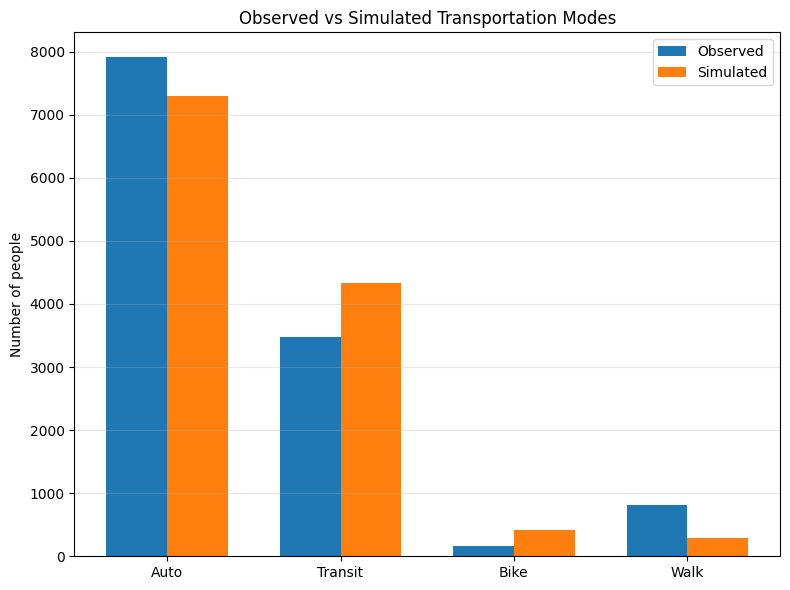

In [16]:
Optimized_betas = np.load("/content/drive/MyDrive/Transportation_UrbanHealth/Betas_MediumComplexity.npy")

agents = Transport_model.agent_list
sample_size = int(0.30 * len(agents)) # 30% of agents

selected_agents = random.sample(agents, sample_size)

# Assigning new residential and workplaces
for agent in tqdm(selected_agents, desc="Number of agents changing their workplaces and residential places: "):
  new_res = Transport_model.residential.sample(n=1)
  agent.res_id = new_res['res_id'].iloc[0]
  agent.assign_nodes()

for step in range(1):
  Transport_model.compute_all_travel_times(selected_agents)

  agent_df = Transport_model.datacollector.get_agent_vars_dataframe()
  agent_df["time_transit"] = agent_df["time_home_stm"] + agent_df["time_stm_stm"] + agent_df["time_stm_work"]

  for agent in selected_agents:
    agent.compute_mode_choice(Optimized_betas, agent_df)


counts = {'auto':0, 'transit':0, 'bike':0, 'walk':0}

for a in agents:
  if a.mode_choice == "auto": counts['auto'] += 1
  elif a.mode_choice == "transit": counts['transit'] += 1
  elif a.mode_choice == "bike": counts['bike'] += 1
  else: counts['walk'] += 1

observed_counts = np.array([7911, 3483,  161,  817])
'''
observed_counts = np.array([
    round(Transport_model.montreal_da["Car"].sum() / Transport_model.Each_agent_represents),
    round(Transport_model.montreal_da["Transit"].sum() / Transport_model.Each_agent_represents),
    round(Transport_model.montreal_da["Bike"].sum() / Transport_model.Each_agent_represents),
    round(Transport_model.montreal_da["Walk"].sum() / Transport_model.Each_agent_represents)])
'''
simulated_counts = np.array([
    counts["auto"],
    counts["transit"],
    counts["bike"],
    counts["walk"]])


print('Array of observed_counts: ', observed_counts)
print('Array of simulated_counts: ', simulated_counts)

print('Sum of observed_counts: ', observed_counts.sum())
print('Sum of simulated_counts: ', simulated_counts.sum())


modes = ["Auto","Transit","Bike","Walk"]

x = np.arange(len(modes))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x-width/2,observed_counts,width,label="Observed")

plt.bar(x+width/2,simulated_counts,width,label="Simulated")

plt.xticks(x,modes)

plt.ylabel("Number of people")

plt.title("Observed vs Simulated Transportation Modes")

plt.grid(axis="y",alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()